In [ ]:
!pip install torchmetrics mplcyberpunk torchutils -q

In [ ]:
!pip install transformers -q

In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import transformers

import pandas as pd
import numpy as np
import re
import time
import joblib
import html

from tqdm import tqdm

from transformers import BertTokenizer
from collections import Counter
from transformers import BertTokenizer, BertModel, BertConfig
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report, precision_recall_fscore_support

import mplcyberpunk
plt.style.use("cyberpunk")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_json('/content/drive/MyDrive/healthcare_facilities_reviews.jsonl', lines=True)
df.head()

,review_id,category,title,content,sentiment,source_url
0,0,Поликлиники стоматологические,Классный мастер,Огромное спасибо за чудесное удаление двух зуб...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2727539
1,1,Поликлиники стоматологические,Замечательный врач,Хочу выразить особую благодарность замечательн...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2302877
2,2,Поликлиники стоматологические,Благодарность работникам рентгена,Добрый вечер! Хотелось бы поблагодарить сотруд...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2815031
3,3,Поликлиники стоматологические,Доктор Рабинович,Женщины советского образца в регистратуре не и...,negative,http://www.spr.ru/forum_vyvod.php?id_tema=3443161
4,4,Поликлиники стоматологические,Есть кому сказать спасибо,У меня с детства очень плохие зубы (тонкая и х...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2592430


In [ ]:
# df = pd.read_json('data/healthcare_facilities_reviews.jsonl', lines=True)
# df.head()

In [ ]:
df.isnull().sum()

,0
review_id,0
category,0
title,0
content,0
sentiment,0
source_url,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70597 entries, 0 to 70596
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   review_id   70597 non-null  int64 
 1   category    70597 non-null  object
 2   title       70597 non-null  object
 3   content     70597 non-null  object
 4   sentiment   70597 non-null  object
 5   source_url  70597 non-null  object
dtypes: int64(1), object(5)
memory usage: 3.2+ MB


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
results = []

In [ ]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # HTML
    text = re.sub(r'<.*?>', ' ', text)

    # URL
    text = re.sub(r'http[s]?://\S+|www\.\S+', ' ', text)

    # email
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)

    # lower
    text = text.lower()

    # убрать мусор, сохранить пунктуацию !?.,…
    text = re.sub(r'[^а-яА-ЯёЁa-zA-Z0-9!?.,…\s-]', ' ', text)

    # !!! → !
    text = re.sub(r'!{2,}', '!', text)

    # ??? → ?
    text = re.sub(r'\?{2,}', '?', text)

    # пробелы
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df['cleaned_reviews'] = df['content'].astype(str).apply(clean_text)

In [ ]:
df[['content', 'cleaned_reviews']].head()

,content,cleaned_reviews
0,Огромное спасибо за чудесное удаление двух зуб...,огромное спасибо за чудесное удаление двух зуб...
1,Хочу выразить особую благодарность замечательн...,хочу выразить особую благодарность замечательн...
2,Добрый вечер! Хотелось бы поблагодарить сотруд...,добрый вечер! хотелось бы поблагодарить сотруд...
3,Женщины советского образца в регистратуре не и...,женщины советского образца в регистратуре не и...
4,У меня с детства очень плохие зубы (тонкая и х...,у меня с детства очень плохие зубы тонкая и хр...


In [ ]:
dist = df['sentiment'].value_counts().reset_index()
dist.columns = ['label', 'count']
dist['percent'] = dist['count'] / dist['count'].sum() * 100
dist

,label,count,percent
0,positive,41419,58.669632
1,negative,29178,41.330368


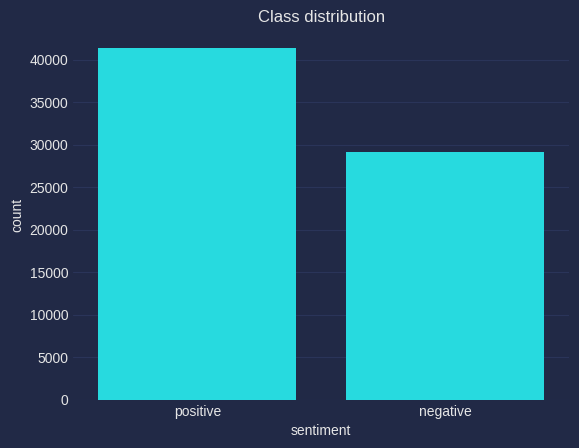

In [ ]:
sns.countplot(x=df['sentiment'])
plt.title("Class distribution")
plt.show()

In [ ]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [ ]:
# X, y
X = df['cleaned_reviews']
y = df['sentiment']

# 1. Train + Temp (80% / 20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. Temp → Valid + Test (10% / 10%)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train), "Valid:", len(X_valid), "Test:", len(X_test))

(56477, 7060, 7060)

In [ ]:
log_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50000,
        min_df=3
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="saga",
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Train
t0 = time.time()
log_clf.fit(X_train, y_train)
train_time = (time.time() - t0) * 1000

# Train metrics
y_train_pred = log_clf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred, average="macro")
train_loss = log_loss(y_train, log_clf.predict_proba(X_train))

# Validation
t0 = time.time()
y_val_pred = log_clf.predict(X_valid)
infer_time = (time.time() - t0) * 1000 / len(X_valid)

val_acc = accuracy_score(y_valid, y_val_pred)
f1_val = f1_score(y_valid, y_val_pred, average="macro")
val_loss = log_loss(y_valid, log_clf.predict_proba(X_valid))

print("Train time (ms):", train_time)
print("Infer time per sample (ms):", infer_time)

print("Train Accuracy:", train_acc)
print("Train F1-macro:", f1_train)
print("Train Log-loss:", train_loss)

print("Valid Accuracy:", val_acc)
print("Valid F1-macro:", f1_val)
print("Valid Log-loss:", val_loss)

Train time (ms): 34646.96407318115
Infer time per sample (ms): 0.1388718994075786
Accuracy (train): 0.9634364431538502
F1-macro (train): 0.9625329913943121
Accuracy (valid): 0.946600566572238
F1-macro (valid): 0.945357130942452


In [ ]:
print("Accuracy (valid):", val_acc)
print("F1-macro (valid):", f1_val)
print(classification_report(y_valid, y_val_pred))

Accuracy (valid): 0.946600566572238
F1-macro (valid): 0.945357130942452
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      2918
           1       0.97      0.94      0.95      4142

    accuracy                           0.95      7060
   macro avg       0.94      0.95      0.95      7060
weighted avg       0.95      0.95      0.95      7060



In [ ]:
cm = confusion_matrix(y_valid, y_valid_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation)")
plt.show()

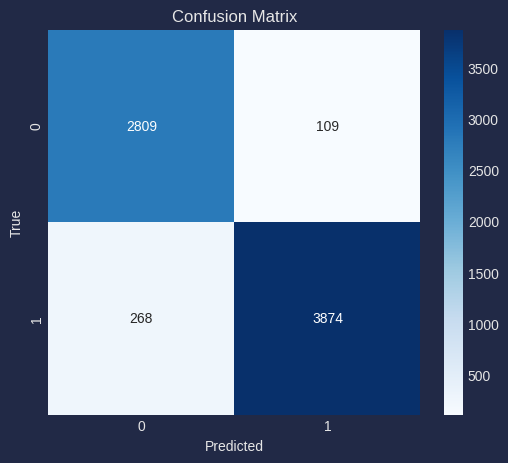

In [ ]:
cm = confusion_matrix(y_valid, y_val_pred, labels=log_clf.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=log_clf.classes_,
            yticklabels=log_clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
prec, rec, f1_cls, _ = precision_recall_fscore_support(
    y_valid, y_valid_pred, labels=[0, 1]
)

plt.figure(figsize=(8, 4))
x = np.arange(2)
plt.bar(x - 0.2, prec, width=0.4, label="Precision")
plt.bar(x + 0.2, rec, width=0.4, label="Recall")
plt.xticks(x, ["negative", "positive"])
plt.title("Precision & Recall by Class")
plt.legend()
plt.show()

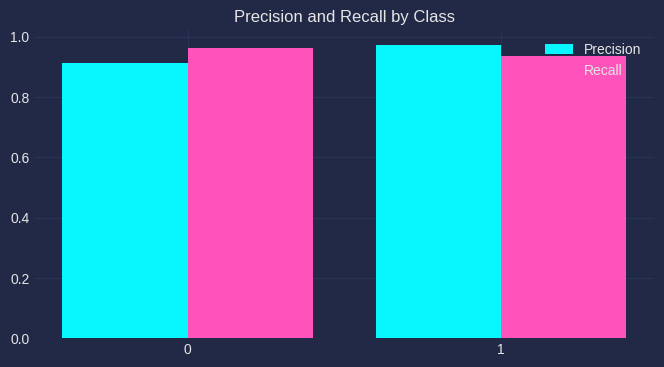

In [ ]:
prec, rec, f1, _ = precision_recall_fscore_support(
    y_valid, y_val_pred, labels=log_clf.classes_
)

plt.figure(figsize=(8,4))
x = np.arange(len(log_clf.classes_))

plt.bar(x - 0.2, prec, width=0.4, label='Precision')
plt.bar(x + 0.2, rec, width=0.4, label='Recall')

plt.xticks(x, log_clf.classes_)
plt.title("Precision and Recall by Class")
plt.legend()
plt.show()

In [ ]:
joblib.dump(log_clf, "baseline_model.pkl")
print("\nSaved baseline_model.pkl")

results.append({
    "model": "TFIDF_LogReg",
    "train_loss": train_loss,
    "train_f1": train_f1,
    "train_acc": train_acc,
    "val_loss": val_loss,
    "val_f1": val_f1,
    "val_acc": val_acc,
    "infer_time_ms_per_sample": infer_time_ms,
    "train_time_ms": train_time_ms
})

import json
with open("baseline_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Saved baseline_results.json")

In [ ]:
# === PARAM COUNT for LogReg ===
clf = log_clf.named_steps["clf"]
tfidf = log_clf.named_steps["tfidf"]

n_features = len(tfidf.get_feature_names_out())
n_params = clf.coef_.size + clf.intercept_.size

print("TF-IDF vocabulary size:", n_features)
print("Logistic Regression parameters:", n_params)

## LSTM

In [ ]:
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_json('/content/drive/MyDrive/healthcare_facilities_reviews.jsonl', lines=True)
df.head()

,review_id,category,title,content,sentiment,source_url
0,0,Поликлиники стоматологические,Классный мастер,Огромное спасибо за чудесное удаление двух зуб...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2727539
1,1,Поликлиники стоматологические,Замечательный врач,Хочу выразить особую благодарность замечательн...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2302877
2,2,Поликлиники стоматологические,Благодарность работникам рентгена,Добрый вечер! Хотелось бы поблагодарить сотруд...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2815031
3,3,Поликлиники стоматологические,Доктор Рабинович,Женщины советского образца в регистратуре не и...,negative,http://www.spr.ru/forum_vyvod.php?id_tema=3443161
4,4,Поликлиники стоматологические,Есть кому сказать спасибо,У меня с детства очень плохие зубы (тонкая и х...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2592430


In [ ]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # HTML
    text = re.sub(r'<.*?>', ' ', text)

    # URL
    text = re.sub(r'http[s]?://\S+|www\.\S+', ' ', text)

    # emails
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)

    # lower
    text = text.lower()

    # оставляем все буквы, цифры, пунктуацию, эмодзи
    text = re.sub(r'[^а-яёa-z0-9!?.,;:()\'"«»\-\s\U0001F300-\U0001FAFF]', ' ', text)

    # пробелы
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
import json

with open("vocab_LSTM.json", "w", encoding="utf8") as f:
    json.dump(vocab_to_int, f, ensure_ascii=False)

In [ ]:
df['cleaned_reviews'] = df['content'].astype(str).apply(clean_text)

In [ ]:
df[['content', 'cleaned_reviews']].head()

,content,cleaned_reviews
0,Огромное спасибо за чудесное удаление двух зуб...,огромное спасибо за чудесное удаление двух зуб...
1,Хочу выразить особую благодарность замечательн...,хочу выразить особую благодарность замечательн...
2,Добрый вечер! Хотелось бы поблагодарить сотруд...,добрый вечер! хотелось бы поблагодарить сотруд...
3,Женщины советского образца в регистратуре не и...,женщины советского образца в регистратуре не и...
4,У меня с детства очень плохие зубы (тонкая и х...,у меня с детства очень плохие зубы (тонкая и х...


In [ ]:
dist = df['sentiment'].value_counts().reset_index()
dist.columns = ['label', 'count']
dist['percent'] = dist['count'] / dist['count'].sum() * 100
dist

,label,count,percent
0,positive,41419,58.669632
1,negative,29178,41.330368


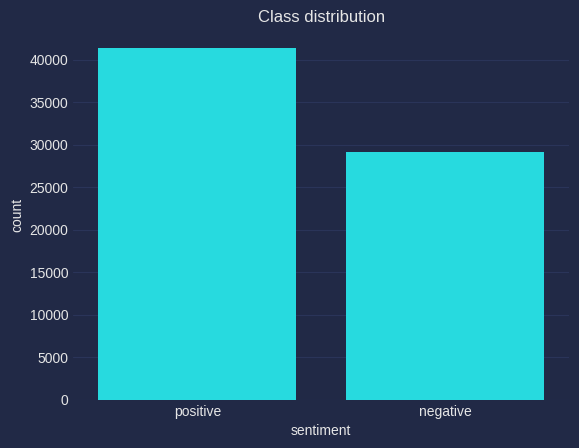

In [ ]:
sns.countplot(x=df['sentiment'])
plt.title("Class distribution")
plt.show()

In [ ]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [ ]:
corpus = [w for text in df['cleaned_reviews'] for w in text.split()]
word_counts = Counter(corpus)
sorted_words = word_counts.most_common(15000)

vocab = [w for w, c in sorted_words if c >= 5]     # отсечение редких слов
vocab_to_int = {w: i+1 for i, w in enumerate(vocab)} # 0 зарезервирован под PAD

In [ ]:
reviews_int = []
for text in df['cleaned_reviews']:
    review = [vocab_to_int[w] for w in text.split() if w in vocab_to_int]
    reviews_int.append(review)

In [ ]:
def padding_tail(reviews, seq_len=200):
    features = np.zeros((len(reviews), seq_len), dtype=int)
    for i, r in enumerate(reviews):
        if len(r) <= seq_len:
            features[i] = np.hstack([np.zeros(seq_len - len(r)), r])
        else:
            features[i] = r[-seq_len:]
    return features

SEQ_LEN = 200
features = padding_tail(reviews_int, SEQ_LEN)
labels = df['sentiment'].values

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    features, labels, test_size=0.2, random_state=1
)

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
valid_ds = TensorDataset(torch.tensor(X_valid), torch.tensor(y_valid))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=128, shuffle=False, drop_last=False)

In [ ]:
class LSTMNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, n_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.dropout = nn.Dropout(0.3)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)
        out, (h, c) = self.lstm(x)
        h_last = h[-1]
        return self.fc(h_last)

In [ ]:
def accuracy(preds, y):
    preds = torch.sigmoid(preds)
    preds = (preds >= 0.5).float()
    return (preds == y).float().mean()


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_acc = 0, 0
    all_y_true = []
    all_y_pred = []

    for X, y in loader:
        X = X.to(device)
        y = y.float().to(device)

        optimizer.zero_grad()
        logits = model(X).squeeze()
        loss = criterion(logits, y)
        acc = accuracy(logits, y)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).int()

        all_y_true.append(y.cpu().numpy().astype(int))
        all_y_pred.append(preds.cpu().numpy().astype(int))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += acc.item()

    all_y_true = np.concatenate(all_y_true)
    all_y_pred = np.concatenate(all_y_pred)
    epoch_f1 = f1_score(all_y_true, all_y_pred, average='macro')

    return total_loss / len(loader), total_acc / len(loader), epoch_f1


def valid_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc = 0, 0
    all_y_true = []
    all_y_pred = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.float().to(device)

            logits = model(X).squeeze()
            loss = criterion(logits, y)
            acc = accuracy(logits, y)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).int()

            all_y_true.append(y.cpu().numpy().astype(int))
            all_y_pred.append(preds.cpu().numpy().astype(int))

            total_loss += loss.item()
            total_acc += acc.item()

    all_y_true = np.concatenate(all_y_true)
    all_y_pred = np.concatenate(all_y_pred)

    epoch_f1 = f1_score(all_y_true, all_y_pred, average='macro')

    return total_loss / len(loader), total_acc / len(loader), epoch_f1

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            self.counter = 0
            return False  # не останавливаемся
        else:
            self.counter += 1
            return self.counter >= self.patience  # True = стоп

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB_SIZE = len(vocab_to_int) + 1
model = LSTMNet(VOCAB_SIZE).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0001)


In [ ]:
model = LSTMClassifier(...)
model.to(device)

# === PARAM COUNT ===
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [ ]:
EPOCHS = 30
early = EarlyStopping(patience=3)

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []
train_f1s, valid_f1s = [], []
infer_times = []
best_val_loss = float("inf")
best_model_path = "best_lstm_model.pt"

for epoch in range(1, EPOCHS + 1):

    # обучение
    t_loss, t_acc, t_f1 = train_epoch(model, train_loader, criterion, optimizer, device)

    # валидация
    v_loss, v_acc, v_f1 = valid_epoch(model, valid_loader, criterion, device)

    train_losses.append(t_loss)
    valid_losses.append(v_loss)
    train_accs.append(t_acc)
    valid_accs.append(v_acc)
    train_f1s.append(t_f1)
    valid_f1s.append(v_f1)

    # уменьшение learning rate, если valid-loss стоит на месте
    scheduler.step(v_loss)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), best_model_path)

        best_metrics = {
            "epoch": epoch,
            "train_loss": float(t_loss),
            "train_acc": float(t_acc),
            "train_f1": float(t_f1),
            "val_loss": float(v_loss),
            "val_acc": float(v_acc),
            "val_f1": float(v_f1),
        }
    # инференс
    t0 = time.time()
    with torch.no_grad():
        for Xb, _ in valid_loader:
            Xb = Xb.to(device)
            _ = model(Xb)

    infer_time = (time.time() - t0) * 1000 / len(X_valid)
    infer_times.append(infer_time)

    print(
        f"Epoch {epoch:02d} | "
        f"TrainLoss={t_loss:.4f} Acc={t_acc:.4f} F1={t_f1:.4f}| "
        f"ValidLoss={v_loss:.4f} Acc={v_acc:.4f} F1={v_f1:.4f}| "
        f"Infer={infer_time:.3f} ms | "
        f"LR={optimizer.param_groups[0]['lr']}"
    )

    # early stopping
    if early.step(v_loss, model):
        print("Early stopping triggered.")
        break

Epoch 01 | TrainLoss=0.4846 Acc=0.7563 F1=0.7437| ValidLoss=0.3534 Acc=0.8449 F1=0.8418| Infer=0.028 ms | LR=0.0005
Epoch 02 | TrainLoss=0.3504 Acc=0.8511 F1=0.8476| ValidLoss=0.3303 Acc=0.8657 F1=0.8638| Infer=0.028 ms | LR=0.0005
Epoch 03 | TrainLoss=0.3079 Acc=0.8737 F1=0.8704| ValidLoss=0.2892 Acc=0.8859 F1=0.8839| Infer=0.028 ms | LR=0.0005
Epoch 04 | TrainLoss=0.2786 Acc=0.8862 F1=0.8831| ValidLoss=0.3175 Acc=0.8839 F1=0.8798| Infer=0.028 ms | LR=0.0005
Epoch 05 | TrainLoss=0.2613 Acc=0.8964 F1=0.8935| ValidLoss=0.2390 Acc=0.9048 F1=0.9023| Infer=0.028 ms | LR=0.0005
Epoch 06 | TrainLoss=0.2420 Acc=0.9069 F1=0.9044| ValidLoss=0.2293 Acc=0.9112 F1=0.9076| Infer=0.028 ms | LR=0.0005
Epoch 07 | TrainLoss=0.2273 Acc=0.9144 F1=0.9120| ValidLoss=0.2046 Acc=0.9219 F1=0.9195| Infer=0.029 ms | LR=0.0005
Epoch 08 | TrainLoss=0.2135 Acc=0.9189 F1=0.9166| ValidLoss=0.2159 Acc=0.9210 F1=0.9189| Infer=0.029 ms | LR=0.0005
Epoch 09 | TrainLoss=0.1978 Acc=0.9267 F1=0.9246| ValidLoss=0.1916 Acc=0

In [ ]:
results.append({
    "model": "LSTM",

    "train_loss": train_losses[-1],
    "train_f1": train_f1s[-1],
    "train_acc": train_accs[-1],

    "val_loss": valid_losses[-1],
    "val_f1": valid_f1s[-1],
    "val_acc": valid_accs[-1],

    "epoch_time": epoch_times_lstm[-1],     # время последней эпохи
    "total_time": total_time_lstm
})

In [ ]:
import json
json.dump(best_metrics, open("metrics_LSTM.json", "w"))

In [ ]:
avg_infer = float(sum(infer_times) / len(infer_times))
best_metrics["avg_infer_ms"] = avg_infer
json.dump(best_metrics, open("metrics_LSTM.json", "w"))

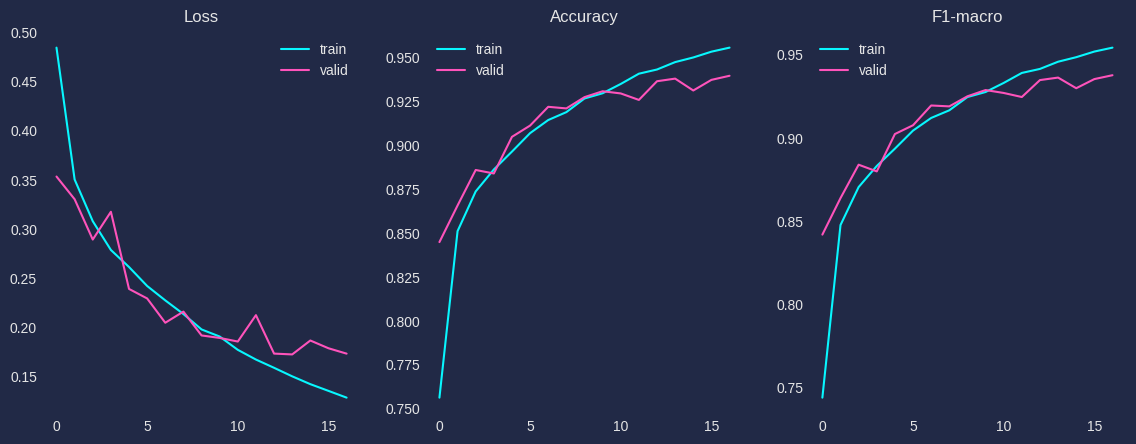

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
plt.plot(train_losses, label='train')
plt.plot(valid_losses, label='valid')
plt.title("Loss")
plt.grid()
plt.legend()

plt.subplot(1,3,2)
plt.plot(train_accs, label='train')
plt.plot(valid_accs, label='valid')
plt.title("Accuracy")
plt.grid()
plt.legend()

plt.subplot(1,3,3)
plt.plot(train_f1s, label='train')
plt.plot(valid_f1s, label='valid')
plt.title("F1-macro")
plt.grid()
plt.legend()

plt.show()

In [ ]:
def preprocess(text, vocab_to_int, seq_len=200):
    tokens = text.split()
    encoded = [vocab_to_int[w] for w in tokens if w in vocab_to_int]
    padded = padding_tail([encoded], seq_len)[0]
    return torch.tensor(padded).unsqueeze(0)

text = "рекомендую эту клинику"
inp = preprocess(text, vocab_to_int).to(device)
logit = model(inp)
prob = torch.sigmoid(logit).item()
print(prob)

0.8339918851852417


## BERT

In [ ]:
df = pd.read_json('/content/drive/MyDrive/healthcare_facilities_reviews.jsonl', lines=True)
df.head()

In [ ]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["cleaned_reviews"] = df["content'"].apply(clean_text)
df = df[["cleaned_reviews", "label"]].dropna().reset_index(drop=True)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    df["cleaned_reviews"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [ ]:
MODEL_NAME = "cointegrated/rubert-tiny2"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
tokenizer.save_pretrained("clinic_tokenizer")

In [ ]:
class ClinicDataset(Dataset):
    def __init__(self, cleaned_reviews, labels, tokenizer, max_len):
        self.cleaned_reviews = list(cleaned_reviews)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        cleaned_reviews = str(self.cleaned_reviews[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            cleaned_reviews,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
            add_special_tokens=True
        )

        return {
            "ids": encoding["input_ids"].squeeze(0),
            "mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
train_dataset = ClinicDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = ClinicDataset(X_val,   y_val,   tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class ClinicClassifier(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name, output_attentions=True)

        # заморозка BERT
        for p in self.bert.parameters():
            p.requires_grad = False

        hidden = 312 if "tiny" in model_name else 768  # rubert-tiny2 → 312 dims

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)   # ← 3 класса
        )

    def forward(self, ids, mask):
        out = self.bert(
            input_ids=ids,
            attention_mask=mask
        )
        cls = out.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        return logits

In [ ]:
model = ClinicClassifier(MODEL_NAME).to(device)

# Проверка, что параметры BERT не тренируются
bert_trainable = sum(p.requires_grad for p in model.bert.parameters())
head_trainable = sum(p.requires_grad for p in model.classifier.parameters())
print("Trainable BERT params:", bert_trainable)
print("Trainable head params:", head_trainable)

In [ ]:
# === PARAM COUNT ===
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.classifier.parameters(),  # только голова
    lr=1e-3,                        # для головы можно оставить 1e-3
    weight_decay=1e-4
)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_true = []
    all_pred = []

    for batch in loader:
        ids = batch["ids"].to(device)
        mask = batch["mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(ids, mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        preds = torch.argmax(logits, dim=1)
        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_true, all_pred, average="macro")
    acc = accuracy_score(all_true, all_pred)

    return avg_loss, f1, acc


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_true = []
    all_pred = []

    with torch.no_grad():
        for batch in loader:
            ids = batch["ids"].to(device)
            mask = batch["mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(ids, mask)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)

            preds = torch.argmax(logits, dim=1)
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_true, all_pred, average="macro")
    acc = accuracy_score(all_true, all_pred)

    return avg_loss, f1, acc, all_true, all_pred

In [ ]:
torch.save(model.state_dict(), "clinic_bert.pt")

In [ ]:
best_f1 = 0.0
best_state = None

total_start = time.perf_counter()   # общий таймер

for epoch in range(EPOCHS):

    epoch_start = time.perf_counter()   # таймер эпохи

    train_loss, train_f1, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_f1, val_acc, _, _ = eval_epoch(
        model, val_loader, criterion, device
    )

    epoch_time = time.perf_counter() - epoch_start   # время эпохи

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f}, F1: {train_f1:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f}, F1: {val_f1:.4f}, Acc: {val_acc:.4f}")
    print(f"  Epoch time: {epoch_time:.2f} sec")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

total_time = time.perf_counter() - total_start
print(f"\nTotal training time: {total_time:.2f} sec")
print(f"Best F1: {best_f1:.4f}")

In [ ]:
results.append({
    "model": MODEL_NAME,
    "train_loss": train_loss_bert,
    "train_f1": train_f1_bert,
    "train_acc": train_acc_bert,
    "val_loss": val_loss_bert,
    "val_f1": val_f1_bert,
    "val_acc": val_acc_bert,
    "epoch_time": last_epoch_time_bert,
    "total_time": total_time_bert
})


In [ ]:
summary_df = pd.DataFrame(results)
summary_df

In [ ]:
summary_df.to_csv("summary_models.csv", index=False)

In [ ]:
def make_attention_html(text, tokenizer, attentions):
    # Берём внимание последнего слоя
    # attentions: list of layers → [batch, heads, seq, seq]
    last = attentions[-1][0]                   # shape: (heads, seq, seq)
    attn = last.mean(dim=0)                    # усредняем по головам → (seq, seq)

    # внимание CLS → все токены
    cls_attn = attn[0].cpu().numpy()           # (seq,)

    # токенизация (должна быть той же, что в тренировке)
    tokens = tokenizer.convert_ids_to_tokens(
        tokenizer(text, truncation=True, padding=True, max_length=128)["input_ids"]
    )

    # удалим [CLS], [SEP], [PAD] — они нам не нужны в подсветке
    clean_tokens = []
    scores = []

    for tok, score in zip(tokens, cls_attn):
        if tok in [tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token]:
            continue
        clean_tokens.append(tok.replace("##", ""))  # делаем читаемо
        scores.append(score)

    scores = np.array(scores)
    if scores.max() > scores.min():
        scores = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        scores = np.zeros_like(scores)

    spans = []
    for tok, score in zip(clean_tokens, scores):
        # делаем фон от белого → красного по силе внимания
        intensity = int(255 * (1 - score))
        color = f"rgb(255,{intensity},{intensity})"
        spans.append(
            f'<span style="background-color:{color}; padding:3px; margin:2px; border-radius:3px;">{html.escape(tok)}</span>'
        )

    return "<div style='line-height:2.0'>" + " ".join(spans) + "</div>"

In [ ]:
def infer_with_attention(text, model, tokenizer, device):
    model.eval()

    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        logits, attentions = model(enc["input_ids"], enc["attention_mask"])

    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred = probs.argmax()

    html_vis = make_attention_html(text, tokenizer, attentions)

    return pred, probs, html_vis

In [ ]:
text = "Doctor was helpful but waiting time was terrible."

pred, probs, html_heatmap = infer_with_attention(text, model, tokenizer, device)

from IPython.display import HTML
HTML(html_heatmap)